# AWI + PQI Combined Analysis

Joins the Awareness Index (AWI) and Pressure Quality Index (PQI) results into a single dataset and produces four publication-ready figures.

**Prerequisites:** `results/awi_full.csv` and `results/pqi_full.csv` must exist.

**Figures produced:**
1. `fig1_awi_vs_pqi_scatter.png` , AWI vs mean PQI scatter, coloured by position
2. `fig2_position_heatmap.png` , position-average AWI and PQI sub-scores heatmap
3. `fig3_half_comparison.png` , 1st vs 2nd half delta for top players
4. `fig4_pqi_decomposition.png` , stacked bar of PQI sub-scores by position

In [1]:
import os, sys
from pathlib import Path

# Find project root (pyproject.toml marker) and chdir to notebooks/
# so ../results/ and ../figures/ resolve correctly from any launch CWD.
_root = next(
    (p for p in [Path().resolve(), *Path().resolve().parents] if (p / "pyproject.toml").exists()),
    None,
)
if _root is None:
    raise RuntimeError("Cannot locate project root  -  pyproject.toml not found.")
os.chdir(_root / "notebooks")
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))


## Step 1. Imports and Setup

Loads standard data-science libraries and sets the Seaborn theme.

In [2]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

## Step 2. Load and Merge AWI + PQI

Left-joins AWI and PQI on `(jersey, team, match_id, phase_label)`.  
Computes the Pearson correlation between `awi_per_minute` and `mean_pqi` and saves the merged dataset.

In [3]:
awi_df = pd.read_csv("../results/awi_full.csv")
pqi_df = pd.read_csv("../results/pqi_full.csv")

# Left-join on join keys
combined = awi_df.merge(
    pqi_df[["jersey", "team", "match_id", "phase_label",
            "mean_pqi", "median_pqi", "std_pqi", "n_press_frames",
            "press_minutes", "orientation_mean", "stance_mean",
            "proximity_mean", "coverage_pct"]],
    on=["jersey", "team", "match_id", "phase_label"],
    how="left",
    suffixes=("", "_pqi"),
)

print(f"Shape: {combined.shape}")
print(f"\nNull counts:\n{combined.isnull().sum()[combined.isnull().sum() > 0]}")

# Pearson correlation between awi_per_minute and mean_pqi
valid = combined[["awi_per_minute", "mean_pqi"]].dropna()
r, p = stats.pearsonr(valid["awi_per_minute"], valid["mean_pqi"])
print(f"\nPearson r(AWI, PQI) = {r:.3f}  (p={p:.4f}, n={len(valid)})")

print(f"\nCombined dataset ready ({len(combined)} rows)")

FileNotFoundError: [Errno 2] No such file or directory: '../results/awi_full.csv'

## Figure 1 , AWI vs PQI Scatter by Position

Each point is one player × phase observation.  
Colour encodes position; the x-axis is scan rate (AWI scans/min) and the y-axis is mean PQI (0–100).

/var/folders/d8/jdj9dp996ps5f3y5m79s3j3m0000gn/T/ipykernel_3417/1724265163.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(positions))


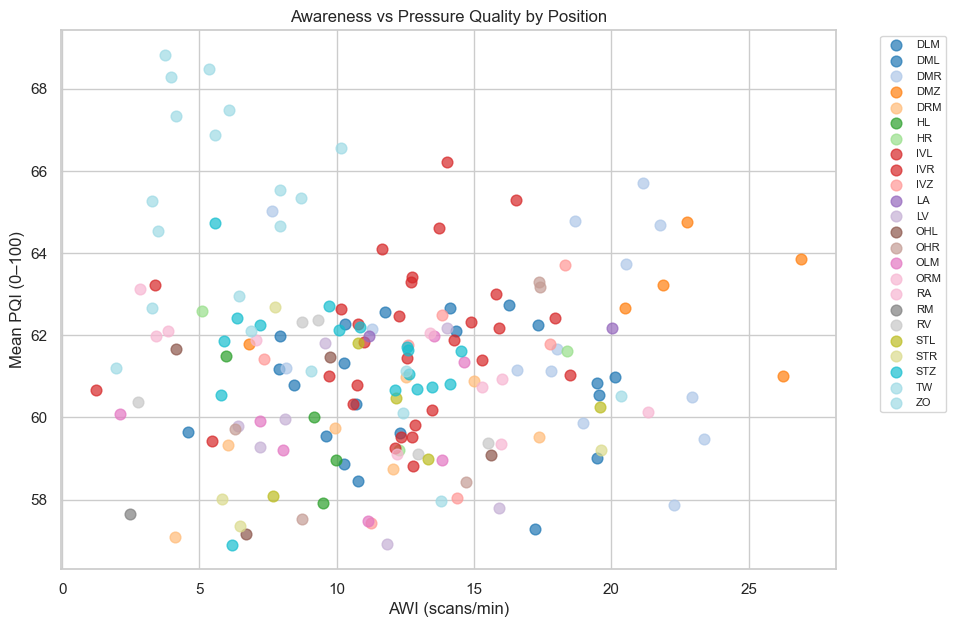

Saved fig1_awi_vs_pqi_scatter.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
positions = combined["position"].dropna().unique()
cmap = plt.cm.get_cmap("tab20", len(positions))
for i, pos in enumerate(sorted(positions)):
    grp = combined[combined["position"] == pos]
    ax.scatter(grp["awi_per_minute"], grp["mean_pqi"],
               label=pos, alpha=0.7, color=cmap(i), s=60)
ax.set_xlabel("AWI (scans/min)")
ax.set_ylabel("Mean PQI (0\u2013100)")
ax.set_title("Awareness vs Pressure Quality by Position")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
fig.savefig("../figures/fig1_awi_vs_pqi_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig1_awi_vs_pqi_scatter.png")

## Figure 2 , Position-Average Heatmap

Aggregates AWI and PQI sub-scores by position group and renders them as an annotated heatmap.  
Useful for spotting which roles tend to scan more or press with higher quality.

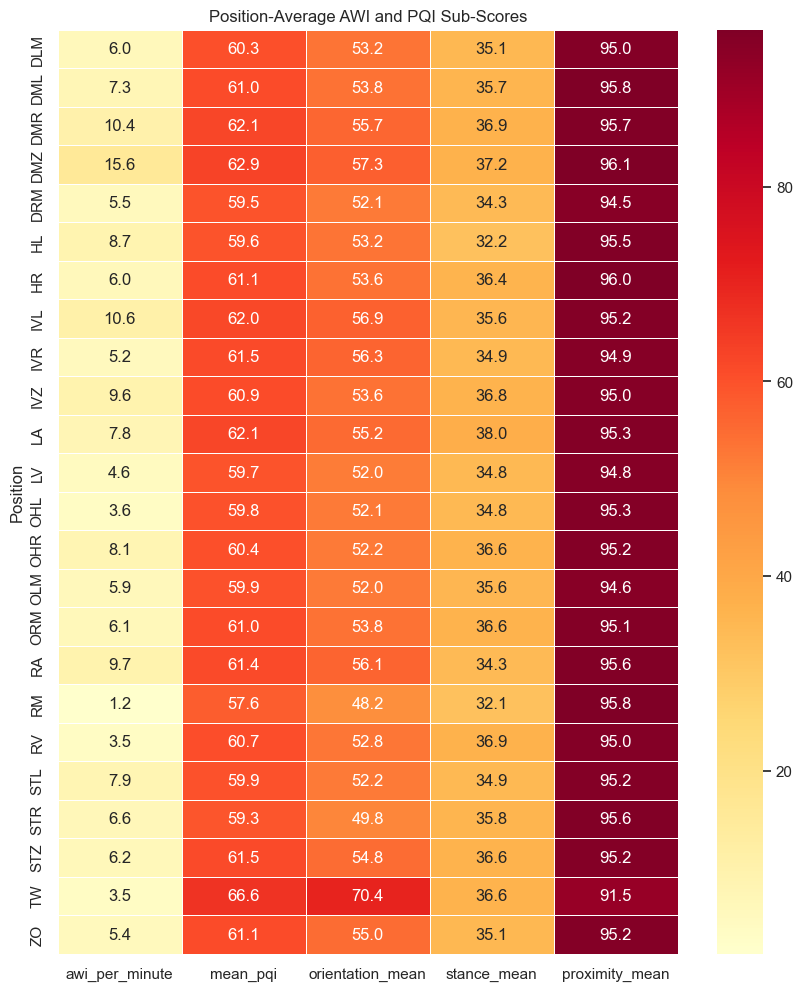

Saved fig2_position_heatmap.png


In [ ]:
heatmap_cols = ["awi_per_minute", "mean_pqi", "orientation_mean", "stance_mean", "proximity_mean"]
pos_avg = combined.groupby("position")[heatmap_cols].mean().dropna(how="all")

fig, ax = plt.subplots(figsize=(10, max(4, len(pos_avg) * 0.5)))
sns.heatmap(pos_avg, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax, linewidths=0.5)
ax.set_title("Position-Average AWI and PQI Sub-Scores")
ax.set_xlabel("")
ax.set_ylabel("Position")
fig.savefig("../figures/fig2_position_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig2_position_heatmap.png")

## Figure 3. Half-Time Delta (Top 15 Players)

For the 15 players with the highest 1st-half AWI, shows how their AWI and PQI changed between halves.  
Positive bars indicate improvement in the 2nd half; negative bars indicate fatigue or tactical adjustment.

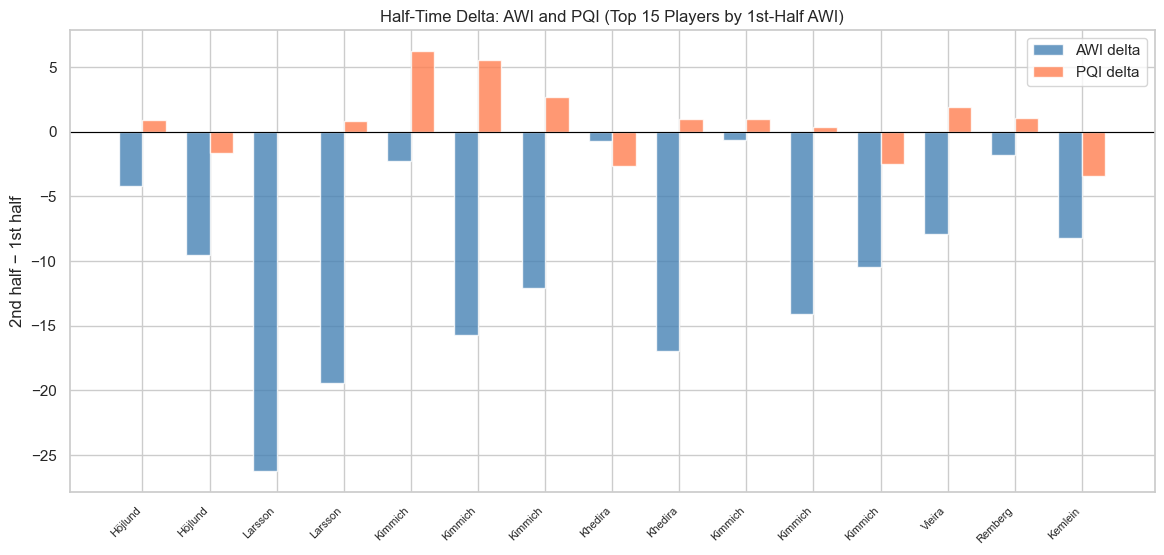

Saved fig3_half_comparison.png


In [ ]:
half1 = combined[combined["phase_label"] == "1st half"][["name", "awi_per_minute", "mean_pqi"]].rename(
    columns={"awi_per_minute": "awi_h1", "mean_pqi": "pqi_h1"})
half2 = combined[combined["phase_label"] == "2nd half"][["name", "awi_per_minute", "mean_pqi"]].rename(
    columns={"awi_per_minute": "awi_h2", "mean_pqi": "pqi_h2"})
halves = half1.merge(half2, on="name", how="inner")
halves["awi_delta"] = halves["awi_h2"] - halves["awi_h1"]
halves["pqi_delta"] = halves["pqi_h2"] - halves["pqi_h1"]
top = halves.nlargest(15, "awi_h1")

x = range(len(top))
width = 0.35
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar([i - width/2 for i in x], top["awi_delta"], width, label="AWI delta", color="steelblue", alpha=0.8)
ax.bar([i + width/2 for i in x], top["pqi_delta"], width, label="PQI delta", color="coral", alpha=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(top["name"].str.split().str[-1], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("2nd half \u2212 1st half")
ax.set_title("Half-Time Delta: AWI and PQI (Top 15 Players by 1st-Half AWI)")
ax.legend()
fig.savefig("../figures/fig3_half_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig3_half_comparison.png")

## Figure 4. PQI Sub-Score Decomposition by Position

Stacked bar chart showing the mean contribution of each PQI sub-score (Orientation, Stance, Proximity) per position group.  
Reveals which aspects of pressing quality differ most across roles.

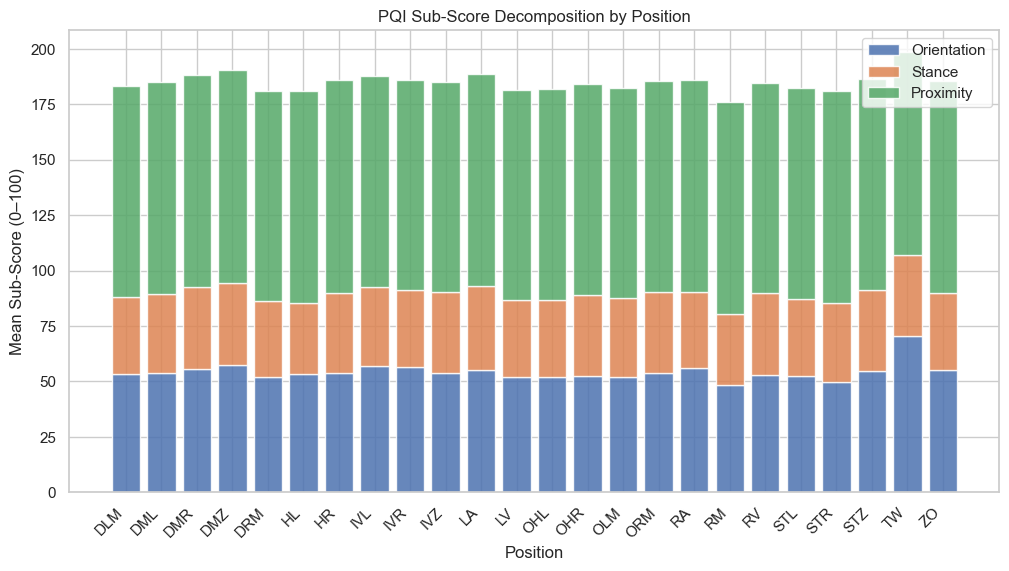

Saved fig4_pqi_decomposition.png


In [ ]:
sub_cols = ["orientation_mean", "stance_mean", "proximity_mean"]
pos_sub = combined.groupby("position")[sub_cols].mean().dropna(how="all")

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(pos_sub))
colors = ["#4C72B0", "#DD8452", "#55A868"]
labels = ["Orientation", "Stance", "Proximity"]
for col, color, label in zip(sub_cols, colors, labels):
    vals = pos_sub[col].fillna(0).values
    ax.bar(pos_sub.index, vals, bottom=bottom, label=label, color=color, alpha=0.85)
    bottom += vals
ax.set_xlabel("Position")
ax.set_ylabel("Mean Sub-Score (0\u2013100)")
ax.set_title("PQI Sub-Score Decomposition by Position")
ax.legend()
plt.xticks(rotation=45, ha="right")
fig.savefig("../figures/fig4_pqi_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig4_pqi_decomposition.png")